In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import reaktoro as rkt
from scipy.optimize import curve_fit


In [407]:
#evaporation coefficient
def k_evap(tair):
    return (0.575 + 0.011*tair)/580.0
def phs_caco3(tds, ca_caco3, alk_caco3, temp=30):
    a = (np.log10(tds)-1)/10
    b = -13.12*np.log10(temp+273) + 34.55
    c = np.log10(ca_caco3)-0.4
    d = np.log10(alk_caco3)
    return 9.3 + a + b - c - d
def phs_po4(ca_caco3, po4, temp=30):
    return (11.75 - np.log10(ca_caco3) - np.log10(po4) - 2*np.log10(temp))/0.65
def predict_ph(alk_caco3, a=4.17, b=1.7177):
    return a + b * np.log10(alk_caco3)
def calc_psi(row):
    ca = row.ca_caco3
    po4 = row.po4_orto
    temp = 30
    ph = row.ph
    return ph - phs_po4(ca, po4, temp)
def calc_lsi(row, temp=70):
    ca = row.ca_caco3
    alk = row.alk*50
    tds = row.tds
    return ph - phs_caco3(tds, ca, alk, temp)
def build_rr_real(row):
    ca = row.ca_caco3/100.0*40.0
    temp=70 
    alk = row.alk*61
    p = row.po4_orto * 31/95.0
    ph = row.ph
    sol = pp.add_solution_raw({
        'units':       'mg/l',
        'temp':        f'{temp}',
        'pH':          f'{ph}',
        'Ca':          f'{ca}',
        'Alkalinity':  f'{alk} as CaCO3',   # 2.2 мг-экв/л
        'P':           f'{p} as PO4',
    })
    return ccp(sol)
def ccp(sol):
    s = sol.copy()
    ca0 = s.total('Ca', units='mmol')
    s.equalize(['Calcite'], [0.0], in_phase=[0.0])
    out = (ca0 - s.total('Ca', units='mmol')) * 100.0869
    s.forget()
    return out

In [308]:
mu_chem = pd.read_excel("mu_water.xlsx")
mu_chem["rdate"] = pd.to_datetime(mu_chem.rdate)
mu_chem = mu_chem.set_index("rdate")
rr_chem = pd.read_excel("rr_analysis.xlsx", sheet_name="S2CT2")
mu_chem = mu_chem.loc[:,['ph', 'ec', 'tds', 'alk', 'tss', 'ca_caco3', 'cl', 'toc', 'cod', 'tvc',
       'po4_tot', 'po4_orto', 'po4_org']].resample("W").mean()
rr_chem["rdate"] = pd.to_datetime(rr_chem.rdate)
rr_chem = rr_chem.set_index("rdate").resample("W").mean()
corrosion = pd.read_excel("corrosion.xlsx")

/home/alir1982/Documents/KIMEKRUS/TANECO_bp/original/prepared/.pixi/envs/default/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [309]:
alk = rr_chem.alk*50 # as CaCO3
ph = rr_chem.ph
popt, pcov = curve_fit(predict_ph, alk, ph, [1.7177, 4.7177])
# стандартные ошибки параметров
perr = np.sqrt(np.diag(pcov))
print("Errors:", perr)
print(f"A={popt[0]}; B = {popt[1]}")
A = popt[0]
B = popt[1]

Errors: [0.15630851 0.06602982]
A=6.362278974759819; B = 0.9506748520250734


In [310]:
rr_chem["psi"] = rr_chem.apply(calc_psi, axis=1)
rr_chem["lsi"] = rr_chem.apply(calc_lsi, axis=1)

In [313]:
common = rr_chem.index.intersection(mu_chem.index)
rr_chem = rr_chem.loc[common]
mu_chem = mu_chem.loc[common]

In [283]:
cp = []
for i in rr_chem.index:
    row = rr_chem.loc[i]
    try:
        cp +=[build_rr_real(row)]
    except:
        print(row)
        cp +=[0]

ph                  8.650000
ec               1796.500000
tds               937.050000
ca_caco3          605.000000
alk                 6.000000
po4_org                  NaN
lsi                 2.018228
cycles_tds          2.150000
retention_ca             NaN
fe                  2.000000
tss                 0.000000
oil                      NaN
tvc             83750.000000
cl                       NaN
cycles_ca           1.930000
po4_orto                 NaN
po4_tot                  NaN
psi                      NaN
Name: 2022-05-08 00:00:00, dtype: float64


In [419]:
K = 0.90
def cycles_from_ratio(mu, rr, k=K):
    return (rr.tds - k*rr.ca_caco3) / (mu.tds - k*mu.ca_caco3)
rr_chem["cycles_ca"] = rr_chem.ca_caco3/mu_chem.ca_caco3
rr_chem['cycles']    = cycles_from_ratio(mu_chem, rr_chem)
rr_chem['retention_ca'] = rr_chem.cycles_ca/rr_chem.cycles

In [456]:
lsi_pred = []
ccpp_predict = []
cp = []
temp=70
for i in rr_chem.index:
    mu_row = mu_chem.loc[i]
    rr_row = rr_chem.loc[i]
    tds = mu_row.tds
    ca = mu_row.ca_caco3*rr_row.cycles+0.1
    alk = mu_row.alk*50*rr_row.cycles+0.1
    ph = predict_ph(alk, A, B)
    sol = pp.add_solution_raw({
        'units':       'mg/l',
        'temp':        f'{temp}',
        'pH':          f'{ph}',
        'Ca':          f'{ca/50*20*rr_row.cycles}',
        'Alkalinity':  f'{alk*rr_row.cycles} as CaCO3',   # 2.2 мг-экв/л
    })
    try:
        ccpp_predict += [ccp(sol)]
        cp +=[build_rr_real(rr_row)]
    except:
        ccpp_predict += [None]
        cp += [None]
    lsi_pred += [ph - phs_caco3(tds=tds, temp=temp, alk_caco3=alk, ca_caco3=ca)]
rr_chem["lsi"] = rr_chem.apply(calc_lsi, axis=1)

/tmp/ipykernel_59584/787331179.py:13: RuntimeWarning: invalid value encountered in log10
  return a + b * np.log10(alk_caco3)
/tmp/ipykernel_59584/787331179.py:7: RuntimeWarning: invalid value encountered in log10
  c = np.log10(ca_caco3)-0.4
/tmp/ipykernel_59584/787331179.py:8: RuntimeWarning: invalid value encountered in log10
  d = np.log10(alk_caco3)


(2.0, 3.0)

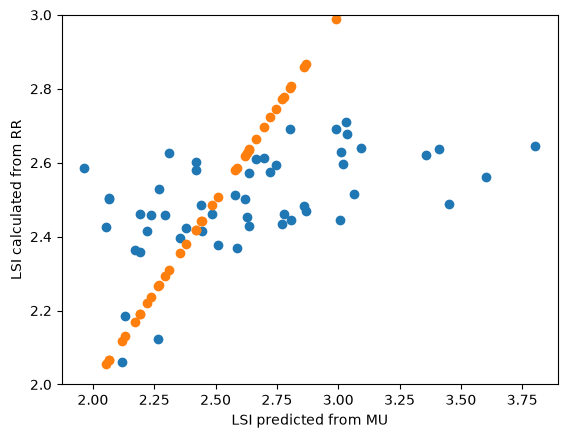

In [457]:
plt.scatter(lsi_pred, rr_chem.lsi)
plt.scatter(lsi_pred, lsi_pred)
plt.xlabel("LSI predicted from MU")
plt.ylabel("LSI calculated from RR")
plt.ylim(2.0, 3.0)

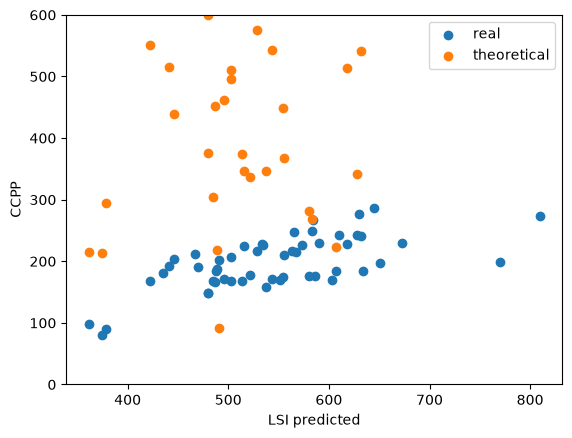

In [470]:
cp = np.array(cp)
plt.scatter(rr_chem.tds, cp, label="real")
plt.scatter(rr_chem.tds, ccpp_predict, label="theoretical")
plt.ylim(0,600)
plt.xlabel("LSI predicted")
plt.ylabel("CCPP")
plt.legend()

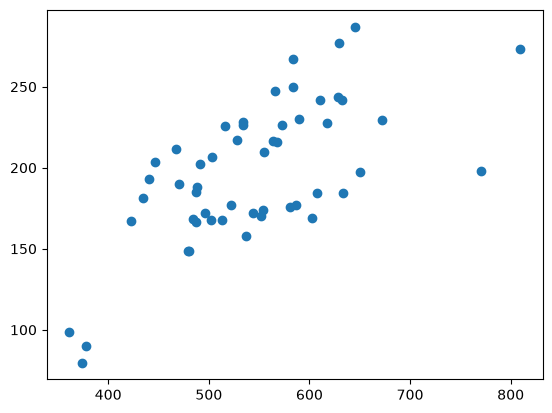

In [463]:
cp = np.array(cp)
plt.scatter(rr_chem.tds, cp)

In [466]:
rr_chem.retention_ca.mean()

np.float64(1.0101781807374035)